In [4]:
import numpy as np
from scipy.stats import truncnorm
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

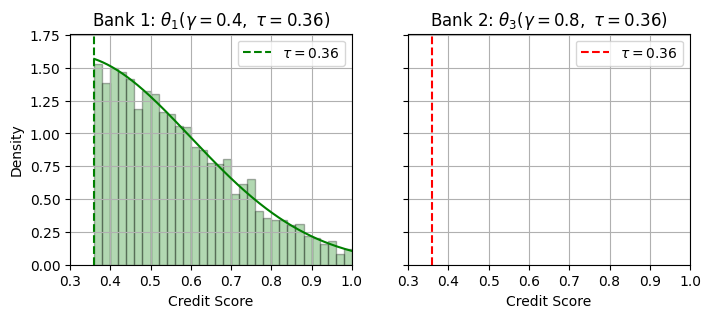

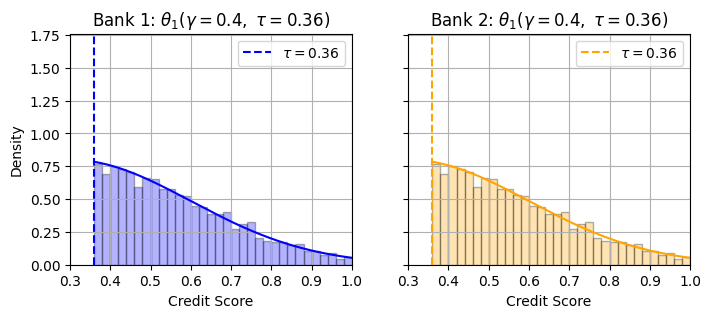

In [5]:
def truncated_gaussian(mu, sigma, lower, upper, size=1000):
    a, b = (lower - mu) / sigma, (upper - mu) / sigma
    return truncnorm(a, b, loc=mu, scale=sigma)

def plot_access_distributions_hist_filtered_symbols():
    mu, sigma = 0.3, 0.3
    lower, upper = 0, 1
    dist = truncated_gaussian(mu, sigma, lower, upper)
    samples = dist.rvs(10000)

    x = np.linspace(lower, upper, 1000)
    pdf = dist.pdf(x)

    # Compute full histogram once
    bin_edges = np.linspace(lower, upper, 51)
    hist_values, _ = np.histogram(samples, bins=bin_edges, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
    xlim = 0.3
    xticks = np.round(np.arange(xlim, 1.01, 0.1), 2)

    # --- First Plot (Tab 1) ---

    # Bank 1: show bins in [0.42, 1]
    mask1 = bin_centers >= 0.36
    ax1.bar(bin_centers[mask1], hist_values[mask1]/2, width=bin_width, alpha=0.3, color='blue', edgecolor='black')
    ax1.plot(x[(x >= 0.36)], pdf[(x >= 0.36)]/2, color='blue')
    ax1.axvline(x=0.36, linestyle='--', color='blue', label=r'$\tau=0.36$')
    ax1.set_title(r'Bank 1: $\theta_1(\gamma=0.4,\ \tau=0.36)$')
    ax1.set_xlabel('Credit Score')
    ax1.set_ylabel('Density')
    ax1.set_xlim([xlim, 1])
    ax1.set_ylim([0, max(pdf) * 1.1])
    ax1.set_xticks(xticks)
    ax1.grid(True)
    ax1.legend()

    # Bank 2: show bins in [0.36, 0.42)
    mask2 = bin_centers >= 0.36
    ax2.bar(bin_centers[mask2], hist_values[mask2]/2, width=bin_width, alpha=0.3, color='orange', edgecolor='black')
    ax2.plot(x[(x >= 0.36)], pdf[(x >= 0.36)]/2, color='orange')
    ax2.axvline(x=0.36, linestyle='--', color='orange', label=r'$\tau=0.36$')
    ax2.set_title(r'Bank 2: $\theta_1(\gamma=0.4,\ \tau=0.36)$')
    ax2.set_xlabel('Credit Score')
    ax2.set_xlim([xlim, 1])
    ax2.set_ylim([0, max(pdf) * 1.1])
    ax2.set_xticks(xticks)
    ax2.grid(True)
    ax2.legend()

    # --- Second Plot (Tab 2) ---

    # Bank 1: show full distribution
    mask3 = bin_centers >= 0.36
    ax3.bar(bin_centers[mask3], hist_values[mask3], width=bin_width, alpha=0.3, color='green', edgecolor='black')
    ax3.plot(x[(x >= 0.36)], pdf[(x >= 0.36)], color='green')
    ax3.axvline(x=0.36, linestyle='--', color='green', label=r'$\tau=0.36$')
    ax3.set_title(r'Bank 1: $\theta_1(\gamma=0.4,\ \tau=0.36)$')
    ax3.set_xlabel('Credit Score')
    ax3.set_ylabel('Density')
    ax3.set_xlim([xlim, 1])
    ax3.set_ylim([0, max(pdf) * 1.1])
    ax3.set_xticks(xticks)
    ax3.grid(True)
    ax3.legend()

    # Bank 2: no access
    ax4.axvline(x=0.36, linestyle='--', color='red', label=r'$\tau=0.36$')
    ax4.set_title(r'Bank 2: $\theta_3(\gamma=0.8,\ \tau=0.36)$')
    ax4.set_xlabel('Credit Score')
    ax4.set_xlim([xlim, 1])
    ax4.set_ylim([0, max(pdf) * 1.1])
    ax4.set_xticks(xticks)
    ax4.grid(True)
    ax4.legend()

    return fig1, fig2

# Generate updated plots with symbolic gamma and tau
fig1, fig2 = plot_access_distributions_hist_filtered_symbols()


In [25]:
from scipy.stats import rv_continuous
def truncated_gaussian(mu=0.3, sigma=0.3, lower=0, upper=1):
    a, b = (lower - mu) / sigma, (upper - mu) / sigma
    return truncnorm(a, b, loc=mu, scale=sigma)

class piecewise_uniform(rv_continuous):
    def __init__(self, tau_l, tau_h, beta1=0.01, beta2=0.95):
        super().__init__(a=0, b=1)
        self.tau_l = tau_l
        self.tau_h = tau_h
        self.beta1 = beta1
        self.beta2 = beta2
        self.beta3 = 1 - (beta1 + beta2)
        self.norm1 = beta1 / tau_l
        self.norm2 = beta2 / (tau_h - tau_l)
        self.norm3 = self.beta3 / (1 - tau_h)

    def _pdf(self, y):
        if y < 0 or y > 1:
            return 0.0
        elif y <= self.tau_l:
            return self.norm1
        elif y <= self.tau_h:
            return self.norm2
        else:
            return self.norm3

def utility_function(gamma, tau_a, tau_b, dist):
    integrand = lambda y: ((2 + gamma) * y - 1) * dist.pdf(y)
    result, _ = quad(integrand, tau_a, tau_b)
    return result

def get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist):
    U1 = np.array([
        [utility_function(gamma_l, tau_l, 1, dist)/2, 0, utility_function(gamma_l, tau_h, 1, dist)/2, 0],
        [utility_function(gamma_l, tau_l, 1, dist), utility_function(gamma_h, tau_l, 1, dist)/2, utility_function(gamma_l, tau_h, 1, dist), utility_function(gamma_h, tau_h, 1, dist)/2],
        [utility_function(gamma_l, tau_l, tau_h, dist) + utility_function(gamma_l, tau_h, 1, dist)/2, utility_function(gamma_h, tau_l, tau_h, dist), utility_function(gamma_l, tau_h, 1, dist)/2, 0],
        [utility_function(gamma_l, tau_l, 1, dist), utility_function(gamma_h, tau_l, tau_h, dist) + utility_function(gamma_h, tau_h, 1, dist)/2, utility_function(gamma_l, tau_h, 1, dist), utility_function(gamma_h, tau_h, 1, dist)/2]
    ])
    return U1

gamma_l, gamma_h = 0.4, 0.8
tau_l, tau_h = 1/(2+gamma_h), 1/(2+gamma_l)
# dist = piecewise_uniform(tau_l, tau_h)
dist = truncated_gaussian(mu=0.3, sigma=0.1)
U1 = get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist)
U1

array([[ 0.00092336,  0.        ,  0.00721543,  0.        ],
       [ 0.00184671,  0.02476377,  0.01443086,  0.01857108],
       [-0.00536872,  0.01238538,  0.00721543,  0.        ],
       [ 0.00184671,  0.03095646,  0.01443086,  0.01857108]])

In [34]:
gamma_l, gamma_h = 0.4, 0.8
mu, sigma = 0.3, 0.1
tau_l, tau_h = 1 / (2 + gamma_h), 1 / (2 + gamma_l)
dist = truncated_gaussian(mu=0.3, sigma=0.1)

pp=utility_function(gamma_l, tau_l, 1, dist)
print(pp)
U1 = get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist)
print(U1)

0.0018467141880154129
[[ 0.00092336  0.          0.00721543  0.        ]
 [ 0.00184671  0.02476377  0.01443086  0.01857108]
 [-0.00536872  0.01238538  0.00721543  0.        ]
 [ 0.00184671  0.03095646  0.01443086  0.01857108]]


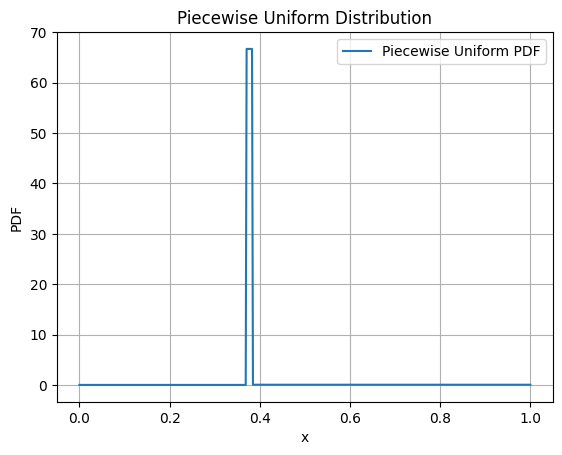

In [76]:
x = np.linspace(0, 1, 500)
y = [dist.pdf(val) for val in x]

plt.plot(x, y, label='Piecewise Uniform PDF')
plt.title("Piecewise Uniform Distribution")
plt.xlabel("x")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()
plt.show()

In [84]:
U1.T.mean(axis=0)

array([0.00580093, 0.02257781, 0.00816916, 0.02486147])

In [78]:
c = U1[1,2] - 2*U1[2,1]
c /= (2*U1[3,3] - U1[3,2] - U1[2,1])
e1 = U1[1,1] - U1[1,2]
e2 = U1[2,1] - U1[2,2]
e1, e2, c

(-0.005480769254716564, 0.002269230769230711, 0.2928039702233183)

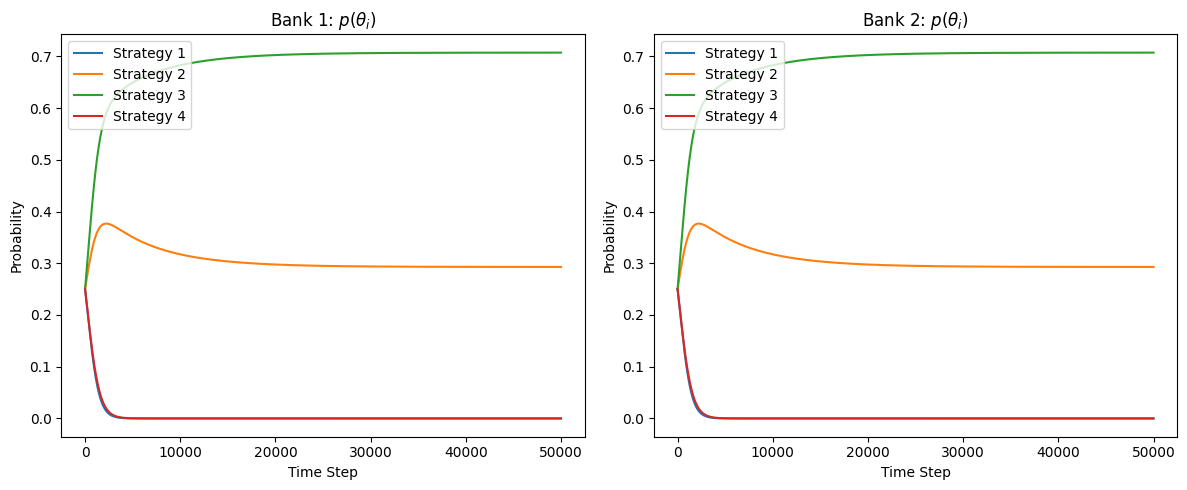

In [21]:
def exponential_weights(T, eta, num_actions, U1):
    p1 = np.ones((T+1, num_actions)) / num_actions
    p2 = np.ones((T+1, num_actions)) / num_actions
    
    U2 = U1  # Assume zero-sum game for illustration
    
    # Simulate algorithm
    for t in range(T):
        for k in range(num_actions):
            # Compute utilities using sampled strategy of the current player
            util1 = np.array([p2[t, j]*U1[j, k] for j in range(num_actions)])
            util2 = np.array([p1[t, j]*U2[j, k] for j in range(num_actions)])
        
            # Update probabilities using exponential weights
            p1[t+1, k] = p1[t, k] * np.exp(eta * util1.sum())
            p2[t+1, k] = p2[t, k] * np.exp(eta * util2.sum())
    
        # Normalize
        p1[t+1] /= np.sum(p1[t+1])
        p2[t+1] /= np.sum(p2[t+1])
    return p1, p2

def plot_probabilities_per_player(p1, p2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i in range(4):
        plt.plot(p1[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 1: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for i in range(4):
        plt.plot(p2[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 2: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


T = 50000  # time steps
eta = 0.1  # learning rate
num_actions = 4  # 4 strategy pairs per player
p1, p2 = exponential_weights(T, eta, num_actions, U1)
plot_probabilities_per_player(p1, p2)

In [68]:
p1[-1], p2[-1]

(array([5.22045484e-46, 9.99999929e-01, 7.13439756e-08, 1.23649126e-39]),
 array([4.35624381e-74, 1.04527267e-18, 3.28153427e-38, 1.00000000e+00]))